<a href="https://colab.research.google.com/github/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar/blob/main/entornos_complejos/lunar_comparation.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Comparación de algoritmos en el problema LunarLander-v3

**Description:** Este notebook unifica y compara el rendimiento de los tres mejores agentes desarrollados para resolver el entorno `LunarLander-v3`:
1. **SARSA Semi-gradiente con Tile Coding**
2. **SARSA Deep Q-Network**
3. **Deep Q-Learning (DQN)**

El objetivo es analizar sus curvas de aprendizaje y estabilidad en una única gráfica comparativa.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/22

## Preparación del entorno

In [ ]:
import sys
if 'google.colab' in sys.modules:
    # Definimos que el entorno es Colab
    en_colab = True
    print("Ejecutando en Google Colab")
else:
    # Definimos que el entorno es local
    en_colab = False
    print("Ejecutando en entorno local")

if en_colab:
    #@title Copiar el repositorio.
    print("Clonando el repositorio, tiempo estimado: 1-2 minutos...")
    !git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
    !cd EML_Carrillo_Ibarrola_Palomar/

    #@title Importamos todas las clases y funciones
    # Añadir los directorio fuentes al path de Python
    sys.path.append('/content/EML_Carrillo_Ibarrola_Palomar/entornos_complejos/')
    # Verificar que se han añadido correctamente
    print(sys.path)

    !pip install -r ./EML_Carrillo_Ibarrola_Palomar/requirements.txt

    dir_base = "./EML_Carrillo_Ibarrola_Palomar/entornos_complejos"
else:
    dir_base = "."

Ejecutando en entorno local


In [ ]:
import sys
import random
import numpy as np
import torch
import gymnasium as gym
from matplotlib import pyplot as plt
from collections import deque
from tqdm import tqdm

# Importamos los agentes de la librería custom
from src.agents import TileCodingEnv, LunarAgentSARSA, SemiGradientSarsaDeepAgent, LunarAgentDeepQLearning

# Fijamos semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- FUNCIONES DE UTILIDAD PARA GRÁFICAS ---
def get_moving_avgs(arr, window: int, convolution_mode: str = "valid"):
    return (np.convolve(np.array(arr).flatten(), np.ones(window), mode=convolution_mode) / window)

def plot_training_metrics_multi(rewards_list, lengths_list, training_errors_list, labels, rolling_length=100, isMonteCarlo=False):
    fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

    # Recompensas
    axs[0].set_title("Episode rewards")
    for rewards, label in zip(rewards_list, labels):
        axs[0].plot(get_moving_avgs(rewards, rolling_length, "valid"), label=label)
    axs[0].set_ylabel("Average Reward")
    axs[0].set_xlabel("Episode")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # Longitudes
    axs[1].set_title("Episode lengths")
    for lengths, label in zip(lengths_list, labels):
        axs[1].plot(get_moving_avgs(lengths, rolling_length, "valid"), label=label)
    axs[1].set_ylabel("Average Episode Length")
    axs[1].set_xlabel("Episode")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # Errores
    title = "Training Evolution" if isMonteCarlo else "Delta_Q (TD Error)"
    ylabel = "Temporal Difference" if isMonteCarlo else "Temporal Difference Error"
    
    axs[2].set_title(title)
    if isMonteCarlo: axs[2].set_yscale("log")
        
    for errors, label in zip(training_errors_list, labels):
        # Manejo de arrays vacíos o diferentes tamaños en errores
        if len(errors) > 0:
            axs[2].plot(get_moving_avgs(errors, rolling_length, "same"), label=label)
            
    axs[2].set_ylabel(ylabel)
    axs[2].set_xlabel("Step")
    axs[2].legend()
    axs[2].grid(True, alpha=0.3)

    for ax in axs:
        ax.tick_params(axis='x', labelrotation=30)

    plt.tight_layout()
    plt.show()

# Listas globales para guardar las métricas de los 3 modelos
all_rewards = []
all_lengths = []
all_errors = []
model_labels = ["SARSA Tiling", "SARSA Deep", "Deep Q-Learning"]

## Experimentos

### 1. Modelo 1: SARSA Semi-gradiente con Tile Coding
En espacios de estados continuos, no podemos usar una tabla $Q$ tradicional. El método *Tile Coding* discretiza el espacio en múltiples cuadrículas superpuestas para aproximar la función de valor.
Para este experimento, utilizamos 5000 episodios y 4 tilings.


In [4]:
print("--- Entrenando SARSA Tiling ---")

# Hiperparámetros
n_episodes_tiling = 5000
learning_rate_tiling = 0.2
initial_epsilon_tiling = 1.0
final_epsilon_tiling = 0.05
ratio_tiling = 0.8

# Entorno
base_env_tiling = gym.make("LunarLander-v3")
bins = np.array([4, 4, 4, 4, 4, 4, 2, 2])
n_tilings = 4

env_tiling = TileCodingEnv(base_env_tiling, low=base_env_tiling.observation_space.low, high=base_env_tiling.observation_space.high, bins=bins, n_tilings=n_tilings)
env_tiling = gym.wrappers.RecordEpisodeStatistics(env_tiling, buffer_length=n_episodes_tiling)
env_tiling.bins = bins
env_tiling.n_tilings = n_tilings

agent_tiling = LunarAgentSARSA(
    env=env_tiling,
    learning_rate=learning_rate_tiling,
    initial_epsilon=initial_epsilon_tiling,
    epsilon_decay=(initial_epsilon_tiling - final_epsilon_tiling) / (n_episodes_tiling * ratio_tiling),
    final_epsilon=final_epsilon_tiling,
    decay_type="linear"
)

# Bucle de entrenamiento adaptado
for n in tqdm(range(n_episodes_tiling)):
    obs, info = env_tiling.reset(seed=n)
    done = False
    action = agent_tiling.get_action(obs)                            
    
    while not done:
        next_obs, reward, terminated, truncated, info = env_tiling.step(action)        
        next_action = agent_tiling.get_action(next_obs)                  
        agent_tiling.update(obs, action, reward, terminated, next_obs, next_action)    
        done = terminated or truncated
        obs = next_obs
        action = next_action

    agent_tiling.decay_epsilon()

all_rewards.append(env_tiling.return_queue)
all_lengths.append(env_tiling.length_queue)
all_errors.append(agent_tiling.training_error)
env_tiling.close()

c:\Users\aaron\miniconda3\envs\dlpln\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


--- Entrenando SARSA Tiling ---


100%|██████████| 5000/5000 [01:10<00:00, 71.29it/s]


### 2. Modelo 2: SARSA Deep Q-Network
Sustituimos la discretización por una Red Neuronal Artificial de 128 neuronas en capas ocultas. Empleamos $\epsilon$-decaimiento para favorecer la exploración inicial y la estabilización posterior, entrenando durante 2000 episodios.

In [5]:
print("--- Entrenando SARSA Deep ---")

# Hiperparámetros (La mejor configuración según el notebook original)
n_episodes_sdeep = 2000
learning_rate_sdeep = 0.001
start_epsilon_sdeep = 1.0
epsilon_decay_sdeep = start_epsilon_sdeep / (n_episodes_sdeep / 2)
final_epsilon_sdeep = 0.05
discount_factor_sdeep = 0.99

env_sdeep = gym.make("LunarLander-v3")
env_sdeep = gym.wrappers.RecordEpisodeStatistics(env_sdeep, buffer_length=n_episodes_sdeep)

agent_sdeep = SemiGradientSarsaDeepAgent(
    env=env_sdeep,
    learning_rate=learning_rate_sdeep,
    epsilon=start_epsilon_sdeep,
    epsilon_decay=epsilon_decay_sdeep,
    final_epsilon=final_epsilon_sdeep,
    discount_factor=discount_factor_sdeep,
    hidden_dim=128 # La que dio mejores resultados (Win Rate: 89.7%)
)

scores_window = deque(maxlen=100)
for t in tqdm(range(n_episodes_sdeep)):
    state, info = env_sdeep.reset(seed=t)
    action, _ = agent_sdeep.get_action(state)
    total_reward = 0
    done = False
    
    while not done:
        next_state, reward, terminated, truncated, _ = env_sdeep.step(action)
        done = terminated or truncated
        
        if not done:
            next_action, _ = agent_sdeep.get_action(next_state)
        else:
            next_action = None
            
        agent_sdeep.update(
            obs=state, action=action, reward=reward,
            terminated=done, next_obs=next_state, next_action=next_action
        )

        state = next_state
        action = next_action
        total_reward += reward
        
    agent_sdeep.decay_epsilon()

all_rewards.append(env_sdeep.return_queue)
all_lengths.append(env_sdeep.length_queue)
# SARSA Deep Agent usa listas de loss diferentes dependiendo de tu implementación exacta.
# Asumimos que guarda la métrica en agent_sdeep.training_error o similar. Si no la guarda, ponemos array vacío.
errors_sdeep = getattr(agent_sdeep, 'training_error', [])
all_errors.append(errors_sdeep)
env_sdeep.close()

--- Entrenando SARSA Deep ---


100%|██████████| 2000/2000 [18:46<00:00,  1.78it/s] 


### 3. Modelo 3: Deep Q-Learning (DQN)
El algoritmo off-policy DQN incorpora dos mejoras cruciales sobre SARSA Deep: el *Experience Replay* (rompe la correlación entre muestras) y una *Target Network* (estabiliza el cálculo del gradiente). 
Utilizamos $\gamma = 0.999$ y un decaimiento de $\epsilon$ de 0.99 (los mejores parámetros detectados).

In [6]:
print("--- Entrenando Deep Q-Learning ---")

n_episodes_dqn = 1500
max_t_dqn = 1000
epsilon_start_dqn = 1.0
epsilon_end_dqn = 0.01
epsilon_decay_dqn = 0.99  # El que dio la curva perfecta
discount_factor_dqn = 0.999 # El mejor factor de descuento analizado

env_dqn = gym.make('LunarLander-v3')
env_dqn = gym.wrappers.RecordEpisodeStatistics(env_dqn, buffer_length=n_episodes_dqn)

state_size = env_dqn.observation_space.shape[0]
action_size = env_dqn.action_space.n

agent_dqn = LunarAgentDeepQLearning(
    env=env_dqn,
    state_size=state_size,
    action_size=action_size,
    epsilon=epsilon_start_dqn,
    epsilon_decay=epsilon_decay_dqn,
    final_epsilon=epsilon_end_dqn,
    discount_factor=discount_factor_dqn,
    seed=SEED
)

for i_episode in tqdm(range(1, n_episodes_dqn + 1)):
    state, _ = env_dqn.reset(seed=i_episode)
    
    for t in range(max_t_dqn):
        action = agent_dqn.get_action(state, agent_dqn.epsilon)
        next_state, reward, done, _, _ = env_dqn.step(action)
        
        agent_dqn.update(state, action, reward, done, next_state)
        state = next_state
        
        if done:
            break 
            
    agent_dqn.decay_epsilon()

all_rewards.append(env_dqn.return_queue)
all_lengths.append(env_dqn.length_queue)
errors_dqn = getattr(agent_dqn, 'training_error', [])
all_errors.append(errors_dqn)
env_dqn.close()

--- Entrenando Deep Q-Learning ---


100%|██████████| 1500/1500 [14:47<00:00,  1.69it/s]


### 4. Comparativa Global de Rendimiento
A continuación mostramos las tres curvas superpuestas para ver claramente las diferencias de aprendizaje, estabilidad y duración de episodios de los tres algoritmos.

Generando gráfica comparativa de los tres algoritmos...


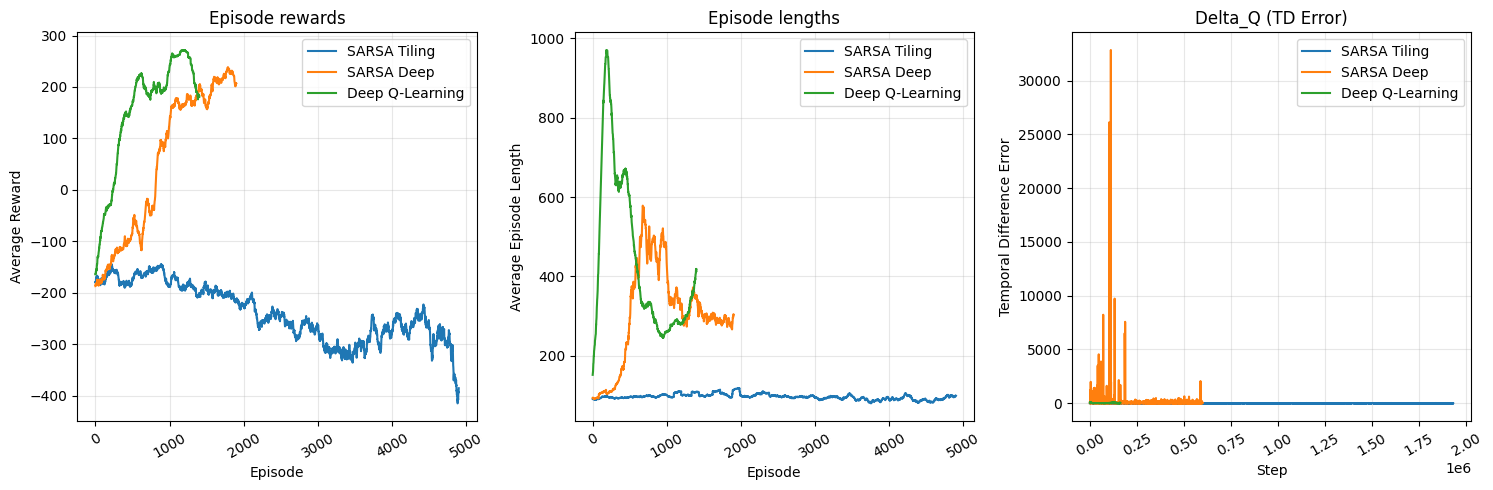

In [7]:
# Convertimos las colas de Gymnasium a listas planas
rewards_formatted = [np.array(r).flatten() for r in all_rewards]
lengths_formatted = [np.array(l).flatten() for l in all_lengths]

print("Generando gráfica comparativa de los tres algoritmos...")
plot_training_metrics_multi(
    rewards_list=rewards_formatted,
    lengths_list=lengths_formatted,
    training_errors_list=all_errors,
    labels=model_labels,
    rolling_length=100 # Suavizado de 100 episodios
)

## Conclusiones

Tras unificar y comparar los tres enfoques en el entorno continuo `LunarLander-v3`, podemos extraer las siguientes conclusiones clave sobre el impacto de las diferentes arquitecturas y algoritmos:

* El algoritmo SARSA utilizando *Tile Coding* se mostró incapaz de resolver el entorno (Win Rate del 0.0% y recompensas medias muy negativas). Aunque la discretización del espacio de estados funciona bien en entornos más simples, el problema de LunarLander cuenta con un espacio continuo de 8 dimensiones y dinámicas no lineales. El *Tile Coding* sufre aquí la "maldición de la dimensionalidad", impidiendo al agente generalizar correctamente para la estabilización y el aterrizaje.

* Al sustituir las cuadrículas por una Red Neuronal Artificial (arquitectura de 128 neuronas en capas ocultas), el agente SARSA logró un avance enorme (Win Rate cercano al 90%). La red neuronal demuestra una capacidad excelente para aproximar la función de valor $Q(s, a)$ en estados continuos. Sin embargo, al ser un algoritmo *on-policy* clásico, su curva de aprendizaje presenta picos de inestabilidad.

* DQN se consolida como el algoritmo ganador para este problema. La clave de su éxito y de su curva de aprendizaje casi perfecta radica en dos mecanismos *off-policy* que SARSA Deep no tiene:
    1.  **Experience Replay (Memoria):** Al muestrear transiciones pasadas de forma aleatoria, rompe la correlación temporal de los datos, estabilizando enormemente los gradientes de la red.
    2.  **Target Network:** Mantener una red objetivo congelada durante varios pasos evita que el objetivo de aprendizaje se mueva constantemente, permitiendo una convergencia mucho más sólida.

* Los experimentos demostraron que tener una buena red no es suficiente. En DQN, configurar el factor de descuento (gamma) en 0.999 fue vital para que el agente valorase la recompensa lejana del aterrizaje (+100) desde el primer segundo de caída. Asimismo, un decaimiento de epsilon de 0.99 proporcionó el equilibrio exacto: suficiente tiempo inicial para explorar choques, y una transición suave hacia la explotación de la política óptima para lograr aterrizajes consistentes por encima de los 200 puntos.

En coclusión, para problemas de control continuo complejo como LunarLander, las Redes Neuronales son indispensables. Además, aislar la actualización de pesos mediante técnicas *off-policy* con memoria (DQN) resulta muy superior en estabilidad y rendimiento a los métodos *on-policy* estándar (SARSA Deep).